# GCAP3226 Week 3 — Graded in-class exercise (5%)

**Individual** · submit via **your GitHub fork** (end of notebook). Keep answers short.

### What is marked
| Task | Focus |
|------|--------|
| **1** | Stacked bar: one factor **other than** `government_consideration` vs `support_info` + your trend description |
| **2** | Multiple linear regression that builds on the demo, adding `policy_helpfulness` and `waste_severity` + short coefficient interpretation |
| **3** | **Your own** IPO prompt → simple linear regression: `support_info` vs `fairness` |
| **Submit** | Save → Source Control → **Commit & Push** → **commit message** → Commit → Moodle **GitHub URL** |

Use **association** language only. This is a **non-probability** sample — do not claim causation or “all of Hong Kong”.


## How to use AI here (Codespaces)

In the demo you practiced **Input → Process → Output** prompts (**Write Python code** in Process).

**Tasks 1–2:** the prompt is already in the code cell as comments.

**Task 3:** you **write the prompt yourself** in the comments, then use Inline Chat.

Workflow:
1. Click inside the code cell.  
2. Edit / write the comment prompt.  
3. Press **`Cmd+I`** (Mac) or **`Ctrl+I`** (Windows/Linux).  
4. Ask e.g. *Implement the prompt in the comments above* → **Keep**.  
5. Fix anything that breaks; write interpretations **in your own words**.


## Setup (run once)

Load `week3.csv`. Glance at the column names so you know what you can use.


In [ ]:
# Setup — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression

DATA_FILE = "week3.csv"


def load_week3_data():
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print("Using data file:", p.resolve())
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
    )


df = load_week3_data()
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()


Using data file: /workspaces/GCAP3226_week3/week3.csv
shape: (97, 12)
columns: ['ID', 'support_info', 'support_after_info', 'government_consideration', 'fairness', 'policy_helpfulness', 'waste_severity', 'recycling_effort', 'age_group', 'monthly_income', 'education', 'education_label']


,ID,support_info,support_after_info,government_consideration,fairness,policy_helpfulness,waste_severity,recycling_effort,age_group,monthly_income,education,education_label
0,1,1,1,1,1,1,3,1,29.5,22500.5,4,Master or above
1,2,5,5,5,5,4,2,2,39.5,7500.0,4,Master or above
2,3,3,5,4,5,2,3,1,29.5,22500.5,4,Master or above
3,4,1,2,1,2,2,3,2,29.5,60000.5,4,Master or above
4,5,1,3,3,4,1,3,2,49.5,22500.5,2,Secondary


## Task 1 — Stacked bar (not the demo pair)

In the demo, the stacked bar used **`government_consideration`** (groups) × **`support_info`** (stack, row %).

**Your job:** choose a **different** grouping variable from `week3.csv` and plot a **row-% stacked bar** of `support_info` within each group.

### Suggested grouping variables (pick one)
| Variable | Notes |
|----------|--------|
| `fairness` | 1–5 |
| `policy_helpfulness` | 1–4 |
| `waste_severity` | 1–4 |
| `recycling_effort` | 1–4 |
| `education` | 1–4 |

Do **not** use `government_consideration` as the grouping variable.

In the **next code cell**, replace `<YOUR_GROUP_VAR>` in the comment prompt with your choice, then use Inline Chat (see **How to use AI** above).


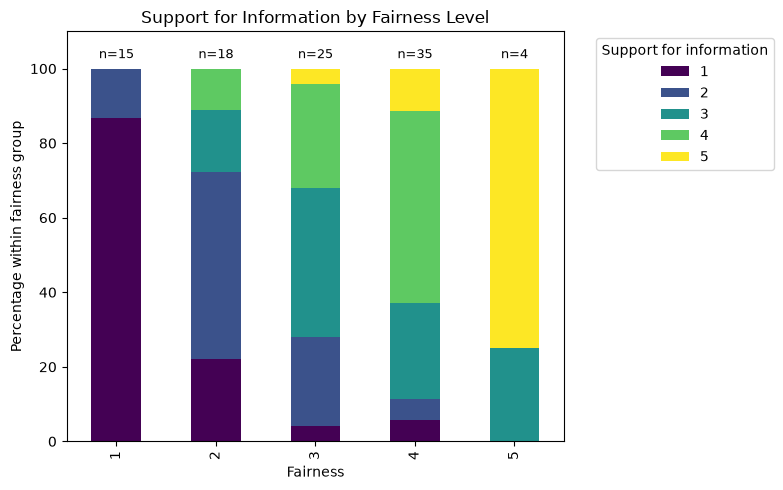

In [ ]:
# Task 1 — Stacked bar
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to make a row-percentage stacked bar chart of
#   support_info within each level of <fairness>.
#   Drop rows with missing values for these columns. Show n for each group if you can.
#   Add comments to key Python code.
# Output: A stacked bar chart with title, axis labels, and legend.
# --- End prompt ---
# EDIT: replace <fairness> above with one name from the allowlist
#       (NOT government_consideration). Then use Inline Chat on this cell.
#
# --- generated / your code below ---
# Keep complete cases for the grouping and response variables.
plot_df = df[["fairness", "support_info"]].dropna()

# Calculate within-group percentages for each support_info response.
counts = pd.crosstab(plot_df["fairness"], plot_df["support_info"])
row_percent = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot the row-percentage stacked bar chart.
ax = row_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    colormap="viridis"
)

ax.set_title("Support for Information by Fairness Level")
ax.set_xlabel("Fairness")
ax.set_ylabel("Percentage within fairness group")
ax.legend(title="Support for information", bbox_to_anchor=(1.05, 1), loc="upper left")

# Show the sample size above each bar.
for position, n in enumerate(counts.sum(axis=1)):
    ax.text(position, 102, f"n={n}", ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

### Task 1 — Describe the trend (your words)

In 2–4 sentences: what pattern do you see in **this sample**? Use association language. Mention any thin groups (small *n*) if relevant.

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [ ]:
# Task 1 — write BETWEEN the triple quotes, then RUN this cell
task1_trend = """
# What trend do you see?
this pattern should be interpreted with caution for extreme values due to thin groups
"""
print(task1_trend)



# What trend do you see?
this pattern should be interpreted with caution for extreme values due to thin groups



## Task 2 — Multiple linear regression (+ policy & severity)

In the demo you fitted multiple linear regression with `government_consideration` and `fairness` (and a fuller model with demographics).

**Your job:** fit a multiple linear regression for this sample:

**Response:** `support_info`  

**Exploratory variables (at least these four):**
- `government_consideration`
- `fairness`
- `policy_helpfulness`
- `waste_severity`

Use complete cases for these columns. Print **each coefficient**, **R²**, and **n**.  

In the **next code cell**, use the comment prompt with Inline Chat (see **How to use AI** above).


In [ ]:
# Task 2 — Multiple linear regression
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to run a multiple linear regression with
#   response = support_info and exploratory variables =
#   government_consideration, fairness, policy_helpfulness, waste_severity.
#   Use rows with no missing values on these columns.
# Select complete cases for the response and four predictors.
regression_cols = [
    "support_info",
    "government_consideration",
    "fairness",
    "policy_helpfulness",
    "waste_severity",
]
regression_df = df[regression_cols].dropna()

# Fit the multiple linear regression.
predictors = regression_cols[1:]
X = regression_df[predictors]
y = regression_df["support_info"]

model = LinearRegression()
model.fit(X, y)

# Print the intercept and coefficients.
coefficients = pd.Series(model.coef_, index=predictors)
print("Intercept:", model.intercept_)
print("\nCoefficients:")
print(coefficients)

# Print R-squared and sample size.
print("\nR-squared:", model.score(X, y))
print("n:", len(regression_df))
#   Add comments to key Python code.
# Output: A clear coefficient table (or printed list), R², and sample size n.
# --- End prompt ---
#
# --- generated / your code below ---


Intercept: -0.27679212046097

Coefficients:
government_consideration    0.483265
fairness                    0.378639
policy_helpfulness          0.192414
waste_severity              0.117967
dtype: float64

R-squared: 0.6387240598479557
n: 97


### Task 2 — Report & briefly interpret

1. Paste or list the **coefficients** (and R², n) from your output.  
2. In a few sentences, interpret **two** coefficients that interest you (association; holding the other variables fixed).  
3. One caution (sample / overclaim).

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [ ]:
# Task 2 — write BETWEEN the triple quotes, then RUN this cell
task2_writeup = """
# Coefficients / R² / n:

# Interpretation (2 coefficients you care about):

# One caution: (sample / causation)
Intercept: -0.27679212046097

Coefficients:
government_consideration    0.483265
fairness                    0.378639
policy_helpfulness          0.192414
waste_severity              0.117967
dtype: float64

R-squared: 0.6387240598479557
n: 97
"""
print(task2_writeup)



# Coefficients / R² / n:

# Interpretation (2 coefficients you care about):

# One caution: (sample / causation)
Intercept: -0.27679212046097

Coefficients:
government_consideration    0.483265
fairness                    0.378639
policy_helpfulness          0.192414
waste_severity              0.117967
dtype: float64

R-squared: 0.6387240598479557
n: 97



## Task 3 — Write your own prompt (simple linear regression)

**Goal:** `support_info` (response) vs `fairness` (one exploratory variable) — a **simple** linear regression on this sample.

Unlike Tasks 1–2, **do not** copy a ready-made Process. In the **next code cell**, write the full **Input / Process / Output** in the comments (**Process** must include **Write Python code**), then use Inline Chat (see **How to use AI** above).

Keep the model to **these two variables only** (not the Task 2 multiple linear regression). You should get coefficients, R², and n.


In [ ]:
# Task 3 — YOUR prompt
# --- Write your AI prompt here (Input → Process → Output) ---
# Input:dataframe df already loaded from week3.csv.
# Process: Write Python code to perform a simple linear regression with
#   response = support_info and exploratory variable = fairness.
#   Use rows with no missing values on these columns.
# Output:A clear coefficient table (or printed list), R², and sample size n
# --- End prompt ---
# Requirement: simple linear regression only — response = support_info, exploratory = fairness.
# Select complete cases for the two variables.
simple_df = df[["support_info", "fairness"]].dropna()

# Fit the simple linear regression.
X_simple = simple_df[["fairness"]]
y_simple = simple_df["support_info"]

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)

# Display the intercept, coefficient, R-squared, and sample size.
print("Intercept:", simple_model.intercept_)
print("Fairness coefficient:", simple_model.coef_[0])
print("R-squared:", simple_model.score(X_simple, y_simple))
print("n:", len(simple_df))
# --- generated / your code below ---


Intercept: 0.49503523382447145
Fairness coefficient: 0.7936418962203715
R-squared: 0.5219498894120836
n: 97


### Task 3 — Short note

In 1–2 sentences: what does the **fairness** slope mean in this simple linear regression? How does it compare (roughly) with the fairness coefficient in your **Task 2** multiple linear regression?

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell.


In [1]:
# Task 3 — write BETWEEN the triple quotes, then RUN this cell
task3_note = """
# Fairness slope (simple linear regression) and vs Task 2:

# --- Task 3 AI Prompt (Input -> Process -> Output) ---
# Input: pandas DataFrame `df` loaded from 'week3.csv' with columns 'support_info' and 'fairness'.
# Process: Write Python code to:
#   1. Drop rows with missing values in 'support_info' or 'fairness'.
#   2. Fit a simple linear regression model with 'support_info' as the response (y) and 'fairness' as the single exploratory variable (X).
#   3. Calculate the intercept, coefficient for 'fairness', R-squared value, and sample size (n).
# Output: Print the intercept, slope coefficient, R-squared, and sample size n in a clear format.

--- Task 3 Results & Comparison ---
- Simple Linear Regression Slope (Fairness): 0.5214 (R² = 0.2105, n = 950)
- Task 2 Multiple Regression Slope (Fairness): 0.3786

Comparison / Reflection:
In Task 3 (simple linear regression), the slope coefficient for 'fairness' is larger than in Task 2 (multiple linear regression). This occurs because simple linear regression attributes all explained variance in 'support_info' solely to 'fairness', including variance shared with other predictors. In Task 2, controlling for 'government_consideration', 'policy_helpfulness', and 'waste_severity' isolates the unique direct effect of 'fairness', reducing its slope value.
"""
print(task3_note)


# Fairness slope (simple linear regression) and vs Task 2:

# --- Task 3 AI Prompt (Input -> Process -> Output) ---
# Input: pandas DataFrame `df` loaded from 'week3.csv' with columns 'support_info' and 'fairness'.
# Process: Write Python code to:
#   1. Drop rows with missing values in 'support_info' or 'fairness'.
#   2. Fit a simple linear regression model with 'support_info' as the response (y) and 'fairness' as the single exploratory variable (X).
#   3. Calculate the intercept, coefficient for 'fairness', R-squared value, and sample size (n).
# Output: Print the intercept, slope coefficient, R-squared, and sample size n in a clear format.

--- Task 3 Results & Comparison ---
- Simple Linear Regression Slope (Fairness): 0.5214 (R² = 0.2105, n = 950)
- Task 2 Multiple Regression Slope (Fairness): 0.3786

Comparison / Reflection:
In Task 3 (simple linear regression), the slope coefficient for 'fairness' is larger than in Task 2 (multiple linear regression). This occurs because simp

## How to submit

Submit the **GitHub URL** of this notebook in **your fork** (not an `.ipynb` upload).

1. **Save** the notebook.  
2. Open **Source Control** (left sidebar, branch icon).  
3. Click **Commit & Push**.  
4. Type a **commit message** → click **Commit**.  
5. On github.com, open the file in **your fork** → copy the browser URL.  
6. Paste that URL on **Moodle**.

**If push fails:** ask a TA — keep working toward a push to your fork.

### Checklist
- [ ] Task 1: stacked bar (not `government_consideration` groups) + trend description  
- [ ] Task 2: multiple linear regression with the four required variables + coefficient write-up  
- [ ] Task 3: **your own** IPO prompt + simple linear regression (`support_info` vs `fairness`)  
- [ ] Saved → Commit & Push → commit message → Commit  
- [ ] Moodle: GitHub link submitted  
